# MPoint2d Class Demonstration

This notebook provides a comprehensive guide to working with the `MPoint2d` class from the `upxo.geoEntities` module. The `MPoint2d` class represents a collection of 2D points and offers various methods for creation, manipulation, and visualization of multi-point geometries.

## Topics Covered

- **Creating multi-point objects** from coordinate arrays
- **Accessing and iterating** through point collections
- **Mathematical operations** including scalar and vector addition
- **Point generation methods** such as rectangular grids and clustered distributions
- **Visualization techniques** for multi-point geometries

This demonstration uses numpy for numerical operations and matplotlib for visualization, showcasing practical applications of the MPoint2d class in geometric computations and spatial analysis.Imports and Setup","Import necessary libraries (numpy, matplotlib) and the MPoint2d class aliased as mp2d for concise usage in demonstrations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.geoEntities.mulpoint2d import MPoint2d as mp2d

### Creating MPoint2d from Random Coordinates

Generate a multi-point object from a 10x2 numpy array of random floats between 0 and 1, demonstrating the `from_coords` class method.

In [2]:
mulpoint2d = mp2d.from_coords(np.random.random((10,2)))

### Accessing Individual Points

Demonstrate indexing into the MPoint2d object to access individual points by position, showing the first (index 0) and last (index 9) coordinate pairs from the collection.

In [3]:
print(mulpoint2d[0], mulpoint2d[9])

[0.38020174 0.78009712] [0.88846069 0.29649885]


### Iterating Through Coordinates"

Demonstrate iteration over the multi-point object to print each coordinate pair, highlighting iterable behavior.

In [4]:
for coord in mulpoint2d:
    print(coord)

[0.38020174 0.78009712]
[0.88706493 0.21220598]
[0.41632336 0.39789244]
[0.48682294 0.03574402]
[7.68167241e-04 7.75167644e-01]
[0.36497488 0.8816541 ]
[0.48148075 0.19692642]
[0.13175697 0.18628654]
[0.23921454 0.17427547]
[0.88846069 0.29649885]


### Adding a Scalar Value
Use the `add` method with a scalar (10) and 'add' operation to offset all points uniformly, showing in-place modification.

In [5]:
mulpoint2d = mp2d.from_coords(np.random.random((10,2)))
mulpoint2d.coords
mulpoint2d.add(toadd=10, operation='add')
mulpoint2d.coords

array([[10.869493  , 10.57078737],
       [10.87860698, 10.08930378],
       [10.83885975, 10.16598402],
       [10.76030166, 10.99072581],
       [10.91294645, 10.95239909],
       [10.4876884 , 10.45147983],
       [10.8621332 , 10.83600405],
       [10.80515005, 10.7025318 ],
       [10.62364435, 10.8758355 ],
       [10.51354247, 10.87576943]])

### Adding a Vector Offset

Apply a vector offset [-10, 20] to all points using the 'add' operation, demonstrating vector addition across the collection.

In [6]:
mulpoint2d = mp2d.from_coords(np.random.random((10,2)))
mulpoint2d.coords
mulpoint2d.add(toadd=[-10, 20], operation='add')
mulpoint2d.coords

array([[-9.49118535, 20.70273933],
       [-9.87426229, 20.97890134],
       [-9.9151625 , 20.80153278],
       [-9.88300986, 20.75007309],
       [-9.71173021, 20.51664053],
       [-9.56280325, 20.27094453],
       [-9.96679663, 20.56707233],
       [-9.27725262, 20.31043905],
       [-9.86651643, 20.89296725],
       [-9.44177615, 20.19358623]])

### Creating a Vector for Operations

Generate a 10x2 random array to use as a vector for subsequent addition operations, setting up for element-wise point modifications.

In [7]:
vector = np.random.random((10, 2))

### Adding Vectors Element-wise

Create MPoint2d from the vector array, then add the same vector to each point, showing how 'add' with matching shapes works for per-point offsets.

In [8]:
mulpoint2d = mp2d.from_coords(vector)
print(mulpoint2d.coords[1], f'. Number of Rows={mulpoint2d.coords.size}')
mulpoint2d.add(toadd=vector, operation='add')
print(mulpoint2d.coords[1], f'. Number of Rows={mulpoint2d.coords.size}')

[0.49948043 0.37886294] . Number of Rows=20
[0.49948043 0.37886294] . Number of Rows=20


### Appending Additional Points
Use 'append' operation to add the vector array as new points to the existing collection, expanding the multi-point object.

In [9]:
mulpoint2d = mp2d.from_coords(vector)
print(mulpoint2d.coords[1], f'. Number of Rows={mulpoint2d.coords.size}')
mulpoint2d.add(toadd=vector, operation='append')
print(mulpoint2d.coords[1], f'. Number of Rows={mulpoint2d.coords.size}')

[0.49948043 0.37886294] . Number of Rows=20
[0.49948043 0.37886294] . Number of Rows=20


### Creating Rectangular Grid
Generate a 5x3 grid of points from x=0 to 1 and y=0 to 1 using `from_rect_grid`, demonstrating structured point distribution.

In [10]:
mp = mp2d.from_rect_grid(0, 1, 5, 0, 1, 3)
mp

UPXO-mp2d. n=15.

### Clustering Around Centroids
Use `from_clustering_around_centroid` to generate points clustered around specified centroids, illustrating point distribution patterns.

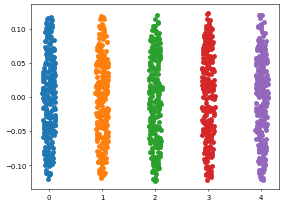

In [11]:
cenx, ceny = [0, 1, 2, 3, 4], [0, 0, 0, 0, 0]
plt.figure(dpi=50)
for cx, cy in zip(cenx, ceny):
    MP2D = mp2d.from_clustering_around_centroid((cx, cy),
                                                n=250, r=0.25,
                                                distribution='urand',
                                                dmin=0.1)
    plt.scatter(MP2D.coords[:,0],MP2D.coords[:,1])

### Advanced Clustering Along a Line

Demonstrate clustering points along a specified line using `from_clustering_along_line`, showing linear distribution patterns.

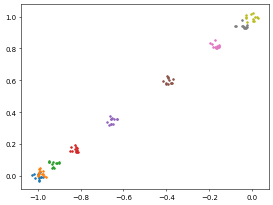

In [12]:
from upxo.geoEntities.mulpoint2d import MPoint2d
from upxo.geoEntities.sline2d import Sline2d
line = Sline2d(-1, 0, 0, 1)
plt.figure(dpi=50)
refpoints = line.distribute_points(n=[5, 3],
                                   spacing='constant', factor=0.6,
                                   sub_spacing=['cubic','cubic'],
                                   subfactors=[0, 1],
                                   trim_ij=True,
                                   _coord_rounding_=(True, 8),
                                   _plot_=False)
for refpnt in refpoints:
    MP2D = MPoint2d.from_clustering_around_centroid((refpnt[0],
                                                     refpnt[1]),
                                                    n=12, r=0.1,
                                                    distribution='urand',
                                                    dmin=0.1)
    plt.plot(MP2D.coords[:,0],MP2D.coords[:,1], '.', ms=5)